In [1]:
#===============================
# Imports
#===============================
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import datetime
import matplotlib.colors as colors
import matplotlib as mpl
from pytz import utc
from matplotlib.lines import Line2D
from dask.distributed import wait
from distributed import Client, LocalCluster
import dask
import pandas as pd
from matplotlib.gridspec import GridSpec

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.img_tiles as cimgt
import shapely.geometry as sgeom
import matplotlib.patheffects as path_effects

import warnings
warnings.filterwarnings("ignore")


/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


# Start Dask Client

In [2]:
iparallel = True

In [3]:
if iparallel:
    dask.config.config["distributed"]["dashboard"]["link"] = "{JUPYTERHUB_SERVICE_PREFIX}proxy/{host}:{port}/status" 
    cluster = LocalCluster(n_workers=100,threads_per_worker=1)
    client = Client(cluster)

In [4]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,Workers: 100
Total threads: 100,Total memory: 476.37 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43311,Workers: 100
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:8787/status,Total threads: 100
Started: Just now,Total memory: 476.37 GiB
Comm: tcp://127.0.0.1:40215,Total threads: 1
Dashboard: /user/mckenna/perlmutter-exclusive-node-cpu/proxy/127.0.0.1:42415/status,Memory: 4.76 GiB
Nanny: tcp://127.0.0.1:42179,


# Observations

In [5]:
obs_path = '/pscratch/sd/m/mckenna/cacti/matched_csapr_goes/'
obs_files = sorted(glob.glob(obs_path+'*_v2.nc'))
num_obs_files = len(obs_files)
print(num_obs_files)

100


## Create pre-processing function that (1) retains only desired variables and (2) trims the domain to the region in which analysis is being performed

In [22]:
lonmin = -64.95
lonmax = -64.65
latmin = -32.9
latmax = -31.1
    
def preprocess_and_subset(ds_single):
    """
    Subsets variables and spatial domain for each file as it's opened.
    Crucially, it computes the boolean masks before using them.
    """
    keep_vars = [
        'ctt','lwp_iwp','opd','col_max_ref', 'ir_tb', 'cth', 'lon', 'lat'
    ]
    ds_single = ds_single[[v for v in keep_vars if v in ds_single]]

    if 'time' in ds_single.coords:
        ds_single['time'] = xr.decode_cf(ds_single).time
    
    # Replace with your actual dimension names
    dim_y = 'south_north'
    dim_x = 'west_east'

    # Create lazy 1D profiles
    mean_lon = ds_single['lon'].mean(dim=dim_y)
    mean_lat = ds_single['lat'].mean(dim=dim_x)

    # Create lazy boolean masks
    lon_mask = (mean_lon >= lonmin) & (mean_lon <= lonmax)
    lat_mask = (mean_lat >= latmin) & (mean_lat <= latmax)

    # ======================================================================
    #  THE FIX: Compute the masks to turn them from lazy Dask arrays
    #  into concrete NumPy boolean arrays before indexing.
    # ======================================================================
    lon_mask_computed = lon_mask.compute()
    lat_mask_computed = lat_mask.compute()
    
    # Now use the computed NumPy masks for subsetting.
    # This works because xarray knows the exact shape of the output.
    ds_trimmed = ds_single.isel(
        {dim_x: lon_mask_computed, dim_y: lat_mask_computed}
    )
    
    return ds_trimmed

## Load data

In [23]:
print("--- Opening and subsetting OBS dataset ---")
ds_obs = xr.open_mfdataset(
    obs_files,
    combine='nested',
    concat_dim='time',
    parallel=True,
    preprocess=preprocess_and_subset,
    combine_attrs="override"  # Good practice when preprocessing
)
ds_obs = ds_obs.sortby('time')

--- Opening and subsetting OBS dataset ---


In [24]:
ds_obs

<xarray.Dataset> Size: 131MB
Dimensions:      (time: 7894, south_north: 66, west_east: 9)
Coordinates:
    lon          (south_north, west_east) float32 2kB dask.array<chunksize=(66, 9), meta=np.ndarray>
    lat          (south_north, west_east) float32 2kB dask.array<chunksize=(66, 9), meta=np.ndarray>
  * time         (time) int64 63kB 1539561603 1539562503 ... 1551571202
Dimensions without coordinates: south_north, west_east
Data variables:
    ctt          (time, south_north, west_east) float32 19MB dask.array<chunksize=(1, 66, 9), meta=np.ndarray>
    lwp_iwp      (time, south_north, west_east) float32 19MB dask.array<chunksize=(1, 66, 9), meta=np.ndarray>
    opd          (time, south_north, west_east) float32 19MB dask.array<chunksize=(1, 66, 9), meta=np.ndarray>
    col_max_ref  (time, south_north, west_east) float64 38MB dask.array<chunksize=(1, 66, 9), meta=np.ndarray>
    ir_tb        (time, south_north, west_east) float32 19MB dask.array<chunksize=(1, 66, 9), meta=np.ndarray>
    cth          (time, south_north, west_east) float32 19MB dask.array<chunksize=(1, 66, 9), meta=np.ndarray>
Attributes:
    title:              Matched-time GOES & CSAPR datasets coarse-grained to ...
    Institution:        Pacific Northwest National Laboratoy
    Contact:            McKenna Stanford, mckenna.stnaford@pnnl.gov
    Created_on:         Sat Aug 30 15:22:48 2025
    source_csapr_path:  /pscratch/sd/m/mckenna/cacti/csapr_coarse_grained_reg...
    source_goes_path:   /global/cfs/projectdirs/m1657/avarble/cacti/3km/satel...
    Date:               20181015

## Get only points where CTT is not NaN and flatten arrays to be in a Pandas dataframe

In [26]:
# 1. Create a lazy boolean mask for all valid 'ctt' values.
#    .notnull() is the idiomatic xarray way to check for non-NaN values.
valid_ctt_mask = ds_obs['ctt'].notnull()

In [28]:
# 2. Apply the mask to the dataset, but WITHOUT `drop=True`.
#    This operation IS supported by Dask. It keeps the original shape,
#    but lazily inserts `NaN` where the mask is False.
#    This makes all variables (opd, ref, etc.) NaN where ctt is NaN.
ds_filtered_with_nans = ds_obs.where(valid_ctt_mask)

In [30]:
# 3. Convert the lazy dataset to a pandas DataFrame.
#    THIS IS THE MAGIC STEP.
#    By default, `to_dataframe()` automatically drops rows where ALL data
#    variables are NaN. Since our `.where()` call created these all-NaN
#    "pixels", they will be efficiently discarded during the conversion process.
#    This step triggers the Dask computation.
print("\n--- Triggering computation and converting to DataFrame... ---")
df_obs = ds_filtered_with_nans.to_dataframe()
df_obs = df_obs.dropna(subset=['ctt'])


--- Triggering computation and converting to DataFrame... ---


In [40]:
df_obs

ctt    lwp_iwp       opd  col_max_ref  \
time       south_north west_east                                                
1539561603 42          3           0.968719  27.378380  4.111944          NaN   
                       4           1.682281  26.022924  3.909667          NaN   
           43          3           0.966370  16.512133  2.478317          NaN   
                       4           1.826202   7.094726  1.065309          NaN   
           46          2           2.408356   6.963541  1.038405          NaN   
...                                     ...        ...       ...          ...   
1551571202 43          3           8.216705  16.156897  2.407396          NaN   
                       4           8.807159   5.317078  0.807946          NaN   
           58          4          11.051666  19.070704  2.466659          NaN   
                       5          10.674683  21.425152  2.991459          NaN   
                       6          11.118835  29.850779  3.320822          NaN   

                                      ir_tb       cth        lon        lat  
time       south_north west_east                                             
1539561603 42          3          11.342560  3.203910 -64.831940 -31.738564  
                       4          11.886475  3.059379 -64.800110 -31.739090  
           43          3          11.302551  3.202382 -64.831299 -31.711510  
                       4          12.034424  3.041824 -64.799500 -31.712044  
           46          2          12.460602  2.972296 -64.861206 -31.629799  
...                                     ...       ...        ...        ...  
1551571202 43          3          13.689972  3.644740 -64.831299 -31.711510  
                       4          14.342224  3.511760 -64.799500 -31.712044  
           58          4          16.323944  2.915145 -64.790283 -31.306229  
                       5          16.017181  2.982024 -64.758606 -31.306755  
                       6          16.194763  2.903275 -64.726929 -31.307266  

[2302848 rows x 8 columns]

## Save to pickle file

In [65]:
# To save the DataFrame to a pickle file
save_path = '/pscratch/sd/m/mckenna/cacti/wrf/ctt_pop_files/'
df_obs.to_pickle(save_path+"obs_ctt_filtered_df.pkl")

## Load pickle file

In [2]:
in_path = '/pscratch/sd/m/mckenna/cacti/wrf/ctt_pop_files/'
df_obs = pd.read_pickle(in_path+"obs_ctt_filtered_df.pkl")

In [3]:
print(np.min(df_obs['lon'].values))
print(np.max(df_obs['lon'].values))
print(np.min(df_obs['lat'].values))
print(np.max(df_obs['lat'].values))
print(np.min(df_obs['cth'].values))
print(np.max(df_obs['cth'].values))

-64.95526
-64.65961
-32.87744
-31.114716
0.92360324
18.715014


## Calculate and plot probability of preciptiation

In [3]:
# Assume 'df_obs_final' is your clean DataFrame from the previous step
# Apply the initial filter for optically thick clouds
df_plot_obs = df_obs[df_obs['opd'] > 10.0].copy()

# For the CTH plot, your original code had a different filter.
# We'll create a separate DataFrame for that.
df_plot_obs_cth = df_obs[(df_obs['opd'] > 10.0) & (df_obs['cth'] >= 0.5)].copy()

In [4]:
def plot_precip_prob(ax, df, variable_to_bin, bins, xlabel, ref_threshes):
    """
    Calculates and plots precipitation probability for a given variable.
    (Corrected version to handle empty bins)
    """
    Fontsize = 11

    # 1. BIN THE DATA (same as before)
    # The labels are the integer index of the bin, from 0 to N-1
    bin_labels = np.arange(len(bins) - 1)
    df['bin'] = pd.cut(df[variable_to_bin], bins=bins, labels=bin_labels, right=True)

    # ======================================================================
    #  THE FIX, PART 1: Convert the bin column to a categorical type.
    #  This tells pandas about all possible bins that *could* exist.
    # ======================================================================
    df['bin'] = pd.Categorical(df['bin'], categories=bin_labels, ordered=True)

    # 2. CALCULATE PROBABILITIES using pandas.groupby
    aggs = {}
    for thresh in ref_threshes:
        aggs[f'prob_{thresh}'] = pd.NamedAgg(
            column='col_max_ref', 
            aggfunc=lambda x, t=thresh: (x > t).mean()
        )
    aggs['count'] = pd.NamedAgg(column='col_max_ref', aggfunc='size')
    
    # ======================================================================
    #  THE FIX, PART 2: Use `observed=False` in the groupby.
    #  This forces pandas to create a row for EVERY category (bin),
    #  even if it's empty in the data.
    # ======================================================================
    binned_stats = df.groupby('bin', observed=False).agg(**aggs)
    
    # Empty bins will result in NaN for the mean and 0 for the count.
    # We should fill the NaN probabilities with 0.
    binned_stats = binned_stats.fillna(0)

    # Now, binned_stats is guaranteed to have the same number of rows
    # as there are bins, so the next step will work perfectly.
    bin_centers = bins[:-1] + np.diff(bins) / 2
    binned_stats['bin_centers'] = bin_centers

    # 3. PLOT THE RESULTS (this part remains the same)
    colors = ['red','darkorange','gold','green','deepskyblue','blue']
    
    for i, thresh in enumerate(ref_threshes):
        ax.plot(binned_stats['bin_centers'], binned_stats[f'prob_{thresh}'], 
                lw=2, c=colors[i], label=f'{thresh} dBZ')

    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.set_ylabel('Probability of Precipitation', fontsize=Fontsize)
    ax.set_xlabel(xlabel, fontsize=Fontsize)
    ax.set_ylim(0)

    ax_hist = ax.twinx()
    
    # 1. Manually calculate the histogram data
    valid_data_for_hist = df.dropna(subset=[variable_to_bin])
    counts, bin_edges = np.histogram(
        valid_data_for_hist[variable_to_bin], 
        bins=bins, 
        density=True
    )
    
    # 2. Plot the result as a Line2D object using ax.plot
    #    'drawstyle="steps-post"' creates the classic histogram shape.
    #    Now, `lw` will have a very clear and predictable effect.
    ax_hist.plot(bin_edges, np.append(counts, counts[-1]), 
                 drawstyle='steps-post', color='k', lw=2, label='PDF')

    
    # We need to drop rows with 0 count for the histogram to be accurate
    # as the original df has NaNs for bins that are out of range
    #valid_data_for_hist = df.dropna(subset=['bin'])
    #ax_hist.hist(valid_data_for_hist[variable_to_bin], bins=bins, histtype='step', 
    #             lw=2, color='k', density=True, label='PDF')
    ax_hist.tick_params(labelsize=Fontsize)
    ax_hist.set_ylabel(f'{variable_to_bin.upper()} Probability Density', fontsize=Fontsize)


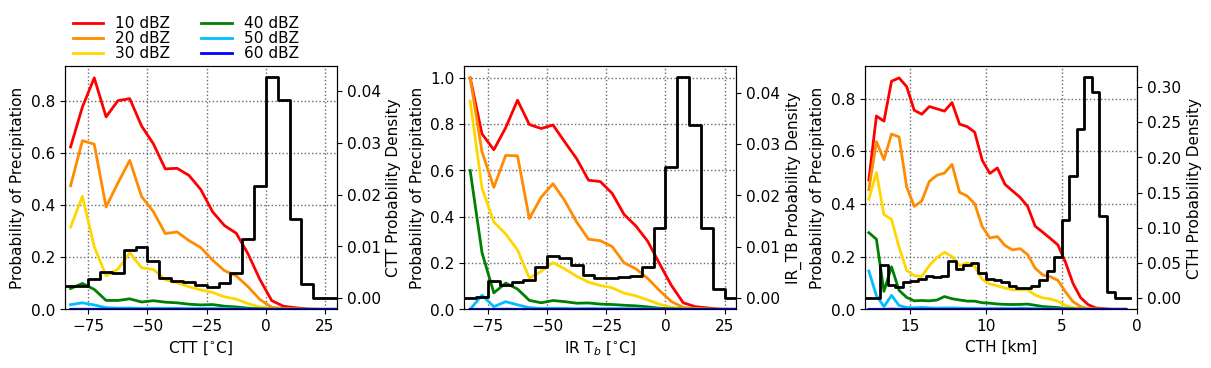

In [5]:
# Define settings
ref_threshes = np.arange(10, 70, 10)
ctt_bins = np.arange(-85, 45, 5)
ir_tb_bins = np.arange(-85, 45, 5)
cth_bins = np.arange(0.5, 18.5, 0.5)

# Create the figure and axes
fig = plt.figure(figsize=(12, 3), constrained_layout=True)
ax1, ax2, ax3 = fig.subplots(1, 3)

# --- Call the function for each subplot ---
plot_precip_prob(ax1, df_plot_obs, 'ctt', ctt_bins, 
                 'CTT [$^{\\circ}$C]', ref_threshes)

plot_precip_prob(ax2, df_plot_obs, 'ir_tb', ir_tb_bins, 
                 'IR T$_{b}$ [$^{\\circ}$C]', ref_threshes)

plot_precip_prob(ax3, df_plot_obs_cth, 'cth', cth_bins, 
                 'CTH [km]', ref_threshes)

# --- Final plot adjustments ---
ax1.set_xlim(-85, 30)
ax2.set_xlim(-85, 30)
ax3.set_xlim(0, 18)
ax3.invert_xaxis() # Special case for CTH plot

# Add a single legend to the first plot
lines, labels = ax1.get_legend_handles_labels()
fig.legend(lines, labels, fontsize=11, framealpha=False, 
           bbox_to_anchor=(0.15, 1.2), loc='upper center', ncol=2,labelspacing=0.01)

plt.show()
plt.close()

# WRF

In [11]:
wrf_path = '/pscratch/sd/m/mckenna/cacti/wrf/derived_3km/'
wrf_files = sorted(glob.glob(wrf_path+'WRF_CACTI_3km_derived_*.nc'))#[::4]
num_wrf_files = len(wrf_files)
print('# of files:',num_wrf_files)

# of files: 8794


In [14]:
for ii in range(3600,3650):
    dum_ds = xr.open_dataset(wrf_files[ii])
    #print(list(dum_ds.keys()))
    print(np.nanmax(dum_ds['cth_tau_ir'].values))
    print(np.nanmin(dum_ds['cth_tau_ir'].values))
    dum_ds.close()

4.487443359375
0.9868469848632813
4.49121728515625
1.114709716796875
4.2728120117187505
1.0069644775390625
4.28509228515625
1.132102294921875
4.305349609375
0.8813726196289062
4.514478515625
1.7376328125
4.7196181640625
1.9911552734375
4.73056884765625
0.30025524902343753
4.7300068359375
2.309657470703125
4.73123486328125
0.6478873901367188
4.75296484375
0.5290231323242187
4.75110302734375
0.523781494140625
4.72086865234375
0.097131591796875
4.69735205078125
0.196191162109375
4.48348486328125
0.6353556518554687
4.28301171875
0.19587353515625
4.07835205078125
0.0969744873046875
4.0500576171875
0.2991663818359375
4.05345849609375
0.1997418212890625
4.05289453125
0.199525146484375
3.24849560546875
0.1994334716796875
1.1274642333984375
0.0986563720703125
1.1273834228515625
0.0986348876953125
1.1272733154296875
0.0986414794921875
1.004753173828125
0.098415283203125
1.006261474609375
0.0983997802734375
1.0062841796875
0.098375244140625
1.00513525390625
0.1996767578125
1.0014671630859375
0.19

In [15]:
lonmin = -64.95
lonmax = -64.65
latmin = -32.9
latmax = -31.1
    
def preprocess_and_subset_wrf(ds_single):
    """
    Subsets variables and spatial domain for each file as it's opened.
    Crucially, it computes the boolean masks before using them.
    """
    keep_vars = [
        'opd_vis','opd_ir','ctt_tau_vis','ctt_tau_ir','col_max_ref', 'ir_tb', 'cth', 'lon', 'lat','twp',
        'cth_tau_vis','cth_tau_ir','ctt_tau_50_50','cth_tau_50_50','opd_50_50'
    ]
    ds_single = ds_single[[v for v in keep_vars if v in ds_single]]

    if 'time' in ds_single.coords:
        ds_single['time'] = xr.decode_cf(ds_single).time
    
    # Replace with your actual dimension names
    dim_y = 'south_north'
    dim_x = 'west_east'

    # Create lazy 1D profiles
    mean_lon = ds_single['lon'].mean(dim=dim_y)
    mean_lat = ds_single['lat'].mean(dim=dim_x)

    # Create lazy boolean masks
    lon_mask = (mean_lon >= lonmin) & (mean_lon <= lonmax)
    lat_mask = (mean_lat >= latmin) & (mean_lat <= latmax)

    # ======================================================================
    #  THE FIX: Compute the masks to turn them from lazy Dask arrays
    #  into concrete NumPy boolean arrays before indexing.
    # ======================================================================
    lon_mask_computed = lon_mask.compute()
    lat_mask_computed = lat_mask.compute()
    
    # Now use the computed NumPy masks for subsetting.
    # This works because xarray knows the exact shape of the output.
    ds_trimmed = ds_single.isel(
        {dim_x: lon_mask_computed, dim_y: lat_mask_computed}
    )
    
    return ds_trimmed

In [ ]:
print("--- Opening and subsetting WRF dataset ---")
ds_wrf = xr.open_mfdataset(
    wrf_files,
    combine='nested',
    concat_dim='time',
    parallel=True,
    preprocess=preprocess_and_subset_wrf,
    combine_attrs="override"  # Good practice when preprocessing
)
ds_wrf = ds_wrf.sortby('time')

--- Opening and subsetting WRF dataset ---


In [14]:
# 1. Create a lazy boolean mask for all valid 'ctt' values.
#    .notnull() is the idiomatic xarray way to check for non-NaN values.
valid_ctt_ir_mask_wrf = ds_wrf['ctt_tau_ir'].notnull()
valid_ctt_vis_mask_wrf = ds_wrf['ctt_tau_vis'].notnull()
valid_ctt_visir5050_mask_wrf = ds_wrf['ctt_tau_50_50'].notnull()

In [15]:
# 2. Apply the mask to the dataset, but WITHOUT `drop=True`.
#    This operation IS supported by Dask. It keeps the original shape,
#    but lazily inserts `NaN` where the mask is False.
#    This makes all variables (opd, ref, etc.) NaN where ctt is NaN.
ds_wrf_filtered_with_nans_vis = ds_wrf.where(valid_ctt_ir_mask_wrf)
ds_wrf_filtered_with_nans_ir = ds_wrf.where(valid_ctt_vis_mask_wrf)
ds_wrf_filtered_with_nans_visir5050 = ds_wrf.where(valid_ctt_visir5050_mask_wrf)

In [16]:
df_wrf_ir = ds_wrf_filtered_with_nans_ir.to_dataframe()
df_wrf_ir = df_wrf_ir.dropna(subset=['ctt_tau_ir'])

In [17]:
df_wrf_vis = ds_wrf_filtered_with_nans_vis.to_dataframe()
df_wrf_vis = df_wrf_vis.dropna(subset=['ctt_tau_vis'])

In [18]:
df_wrf_visir5050 = ds_wrf_filtered_with_nans_visir5050.to_dataframe()
df_wrf_visir5050 = df_wrf_visir5050.dropna(subset=['ctt_tau_50_50'])

In [16]:
save_path = '/pscratch/sd/m/mckenna/cacti/wrf/ctt_pop_files/'
df_wrf_vis.to_pickle(save_path+"wrf_vis_ctt_filtered_df.pkl")
df_wrf_ir.to_pickle(save_path+"wrf_ir_ctt_filtered_df.pkl")
df_wrf_visir5050.to_pickle(save_path+"wrf_visir5050_ctt_filtered_df.pkl")

In [6]:
in_path = '/pscratch/sd/m/mckenna/cacti/wrf/ctt_pop_files/'
df_wrf_vis = pd.read_pickle(in_path+"wrf_vis_ctt_filtered_df.pkl")
df_wrf_ir = pd.read_pickle(in_path+"wrf_ir_ctt_filtered_df.pkl")
df_wrf_visir5050 = pd.read_pickle(in_path+"wrf_visir5050_ctt_filtered_df.pkl")

In [7]:
#df_wrf_ir

In [8]:
df_plot_wrf_vis = df_wrf_vis[df_wrf_vis['opd_vis'] > 10.0].copy()
df_plot_wrf_vis_cth = df_wrf_vis[(df_wrf_vis['opd_vis'] > 10.0) & (df_wrf_vis['cth_tau_vis'] >= 0.5)].copy()

df_plot_wrf_ir = df_wrf_ir[df_wrf_ir['opd_vis'] > 10.0].copy()
df_plot_wrf_ir_cth = df_wrf_ir[(df_wrf_ir['opd_vis'] > 10.0) & (df_wrf_ir['cth_tau_ir'] >= 0.5)].copy()

df_plot_wrf_visir5050 = df_wrf_visir5050[df_wrf_visir5050['opd_vis'] > 10.0].copy()
df_plot_wrf_visir5050_cth = df_wrf_visir5050[(df_wrf_visir5050['opd_vis'] > 10.0) & (df_wrf_visir5050['cth_tau_ir'] >= 0.5)].copy()

In [9]:
def plot_precip_prob(ax, df, variable_to_bin, bins, xlabel, ref_threshes):
    """
    Calculates and plots precipitation probability for a given variable.
    (Corrected version to handle empty bins)
    """
    Fontsize = 11

    # 1. BIN THE DATA (same as before)
    # The labels are the integer index of the bin, from 0 to N-1
    bin_labels = np.arange(len(bins) - 1)
    df['bin'] = pd.cut(df[variable_to_bin], bins=bins, labels=bin_labels, right=True)

    # ======================================================================
    #  THE FIX, PART 1: Convert the bin column to a categorical type.
    #  This tells pandas about all possible bins that *could* exist.
    # ======================================================================
    df['bin'] = pd.Categorical(df['bin'], categories=bin_labels, ordered=True)

    # 2. CALCULATE PROBABILITIES using pandas.groupby
    aggs = {}
    for thresh in ref_threshes:
        aggs[f'prob_{thresh}'] = pd.NamedAgg(
            column='col_max_ref', 
            aggfunc=lambda x, t=thresh: (x > t).mean()
        )
    aggs['count'] = pd.NamedAgg(column='col_max_ref', aggfunc='size')
    
    # ======================================================================
    #  THE FIX, PART 2: Use `observed=False` in the groupby.
    #  This forces pandas to create a row for EVERY category (bin),
    #  even if it's empty in the data.
    # ======================================================================
    binned_stats = df.groupby('bin', observed=False).agg(**aggs)
    
    # Empty bins will result in NaN for the mean and 0 for the count.
    # We should fill the NaN probabilities with 0.
    binned_stats = binned_stats.fillna(0)

    # Now, binned_stats is guaranteed to have the same number of rows
    # as there are bins, so the next step will work perfectly.
    bin_centers = bins[:-1] + np.diff(bins) / 2
    binned_stats['bin_centers'] = bin_centers

    # 3. PLOT THE RESULTS (this part remains the same)
    colors = ['red','darkorange','gold','green','deepskyblue','blue']
    
    for i, thresh in enumerate(ref_threshes):
        ax.plot(binned_stats['bin_centers'], binned_stats[f'prob_{thresh}'], 
                lw=2, c=colors[i], label=f'{thresh} dBZ')

    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    #ax.set_ylabel('Probability of Precipitation', fontsize=Fontsize)
    ax.set_xlabel(xlabel, fontsize=Fontsize)
    ax.set_ylim(0)

    ax_hist = ax.twinx()
    
    # 1. Manually calculate the histogram data
    valid_data_for_hist = df.dropna(subset=[variable_to_bin])
    counts, bin_edges = np.histogram(
        valid_data_for_hist[variable_to_bin], 
        bins=bins, 
        density=True
    )
    
    # 2. Plot the result as a Line2D object using ax.plot
    #    'drawstyle="steps-post"' creates the classic histogram shape.
    #    Now, `lw` will have a very clear and predictable effect.
    ax_hist.plot(bin_edges, np.append(counts, counts[-1]), 
                 drawstyle='steps-post', color='k', lw=2, label='PDF')

    
    # We need to drop rows with 0 count for the histogram to be accurate
    # as the original df has NaNs for bins that are out of range
    #valid_data_for_hist = df.dropna(subset=['bin'])
    #ax_hist.hist(valid_data_for_hist[variable_to_bin], bins=bins, histtype='step', 
    #             lw=2, color='k', density=True, label='PDF')
    ax_hist.tick_params(labelsize=Fontsize)
    #ax_hist.set_ylabel(f'{variable_to_bin.upper()} Probability Density', fontsize=Fontsize)
    #ax_hist.set_ylabel(f'CTT Probability Density', fontsize=Fontsize)
    return ax_hist

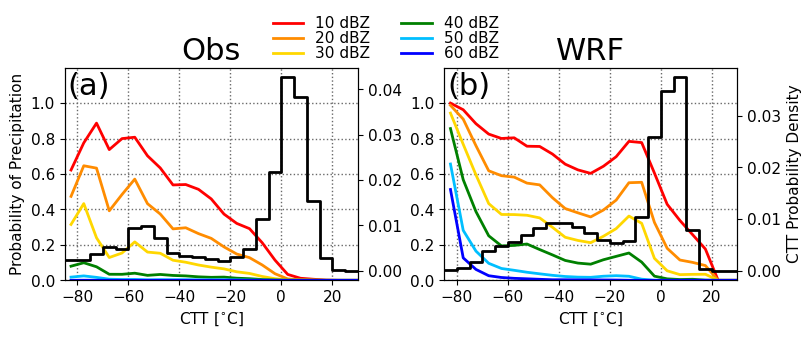

In [10]:
# Define settings
ref_threshes = np.arange(10, 70, 10)
ctt_bins = np.arange(-85, 45, 5)
ir_tb_bins = np.arange(-85, 45, 5)
cth_bins = np.arange(0.5, 18.5, 0.5)

# Create the figure and axes
fig = plt.figure(figsize=(8, 3), constrained_layout=True)
ax1, ax2 = fig.subplots(1, 2)

# --- Call the function for each subplot ---
ax_hist1 = plot_precip_prob(ax1, df_plot_obs, 'ctt', ctt_bins, 
                 'CTT [$^{\\circ}$C]', ref_threshes)
#ax_hist2 = plot_precip_prob(ax2, df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, 
ax_hist2 = plot_precip_prob(ax2, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, 
#ax_hist2 = plot_precip_prob(ax2, df_plot_wrf_visir5050, 'ctt_tau_50_50', ctt_bins, 
                 'CTT [$^{\\circ}$C]', ref_threshes)

Fontsize=11
# --- Final plot adjustments ---
ax1.set_xlim(-85, 30)
ax2.set_xlim(-85, 30)

# Add a single legend to the first plot
lines, labels = ax1.get_legend_handles_labels()
fig.legend(lines, labels, fontsize=Fontsize, framealpha=False, 
           bbox_to_anchor=(0.475, 1.1), loc='upper center', ncol=2,labelspacing=0.01)

ax1.set_title('Obs',fontsize=Fontsize*2.)
ax2.set_title('WRF',fontsize=Fontsize*2.)

ax1.text(0.01,0.98,'(a)',transform=ax1.transAxes,ha='left',va='top',fontsize=Fontsize*2.)
ax2.text(0.01,0.98,'(b)',transform=ax2.transAxes,ha='left',va='top',fontsize=Fontsize*2.)

ax1.set_ylabel('Probability of Precipitation', fontsize=Fontsize)
ax_hist2.set_ylabel(f'CTT Probability Density', fontsize=Fontsize)
ax1.set_ylim(0,1.2)
ax2.set_ylim(0,1.2)
ax1.set_yticks(np.arange(0,1.2,0.2))
ax2.set_yticks(np.arange(0,1.2,0.2))

plt.show()
plt.close()

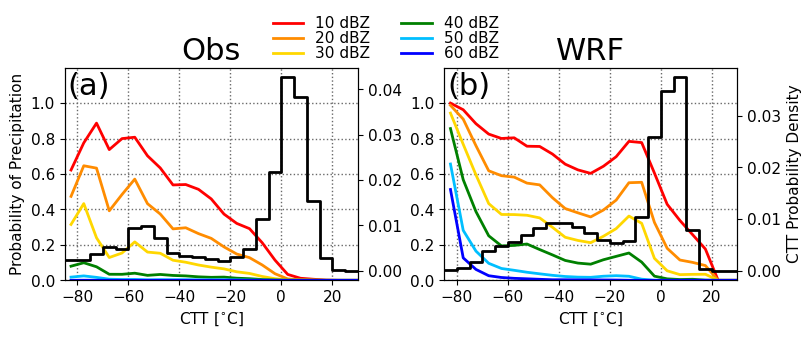

In [12]:
def plot_precip_prob(ax, df, variable_to_bin, bins, xlabel, ref_threshes):
    """
    Calculates and plots precipitation probability for a given variable.
    (Corrected version to handle empty bins)
    """
    Fontsize = 11

    # 1. BIN THE DATA (same as before)
    # The labels are the integer index of the bin, from 0 to N-1
    bin_labels = np.arange(len(bins) - 1)
    df['bin'] = pd.cut(df[variable_to_bin], bins=bins, labels=bin_labels, right=True)

    # ======================================================================
    #  THE FIX, PART 1: Convert the bin column to a categorical type.
    #  This tells pandas about all possible bins that *could* exist.
    # ======================================================================
    df['bin'] = pd.Categorical(df['bin'], categories=bin_labels, ordered=True)

    # 2. CALCULATE PROBABILITIES using pandas.groupby
    aggs = {}
    for thresh in ref_threshes:
        aggs[f'prob_{thresh}'] = pd.NamedAgg(
            column='col_max_ref', 
            aggfunc=lambda x, t=thresh: (x > t).mean()
        )
    aggs['count'] = pd.NamedAgg(column='col_max_ref', aggfunc='size')
    
    # ======================================================================
    #  THE FIX, PART 2: Use `observed=False` in the groupby.
    #  This forces pandas to create a row for EVERY category (bin),
    #  even if it's empty in the data.
    # ======================================================================
    binned_stats = df.groupby('bin', observed=False).agg(**aggs)
    
    # Empty bins will result in NaN for the mean and 0 for the count.
    # We should fill the NaN probabilities with 0.
    binned_stats = binned_stats.fillna(0)

    # Now, binned_stats is guaranteed to have the same number of rows
    # as there are bins, so the next step will work perfectly.
    bin_centers = bins[:-1] + np.diff(bins) / 2
    binned_stats['bin_centers'] = bin_centers

    # 3. PLOT THE RESULTS (this part remains the same)
    colors = ['red','darkorange','gold','green','deepskyblue','blue']
    
    for i, thresh in enumerate(ref_threshes):
        ax.plot(binned_stats['bin_centers'], binned_stats[f'prob_{thresh}'], 
                lw=2, c=colors[i], label=f'{thresh} dBZ')

    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    #ax.set_ylabel('Probability of Precipitation', fontsize=Fontsize)
    ax.set_xlabel(xlabel, fontsize=Fontsize)
    ax.set_ylim(0)

    ax_hist = ax.twinx()
    
    # 1. Manually calculate the histogram data
    valid_data_for_hist = df.dropna(subset=[variable_to_bin])
    counts, bin_edges = np.histogram(
        valid_data_for_hist[variable_to_bin], 
        bins=bins, 
        density=True
    )
    
    # 2. Plot the result as a Line2D object using ax.plot
    #    'drawstyle="steps-post"' creates the classic histogram shape.
    #    Now, `lw` will have a very clear and predictable effect.
    ax_hist.plot(bin_edges, np.append(counts, counts[-1]), 
                 drawstyle='steps-post', color='k', lw=2, label='PDF')

    
    # We need to drop rows with 0 count for the histogram to be accurate
    # as the original df has NaNs for bins that are out of range
    #valid_data_for_hist = df.dropna(subset=['bin'])
    #ax_hist.hist(valid_data_for_hist[variable_to_bin], bins=bins, histtype='step', 
    #             lw=2, color='k', density=True, label='PDF')
    ax_hist.tick_params(labelsize=Fontsize)
    #ax_hist.set_ylabel(f'{variable_to_bin.upper()} Probability Density', fontsize=Fontsize)
    #ax_hist.set_ylabel(f'CTT Probability Density', fontsize=Fontsize)
    return ax_hist



# Define settings
ref_threshes = np.arange(10, 70, 10)
ctt_bins = np.arange(-85, 45, 5)
ir_tb_bins = np.arange(-85, 45, 5)
cth_bins = np.arange(0.5, 18.5, 0.5)

# Create the figure and axes
fig = plt.figure(figsize=(8, 3), constrained_layout=True)
ax1, ax2 = fig.subplots(1, 2)

# --- Call the function for each subplot ---
ax_hist1 = plot_precip_prob(ax1, df_plot_obs, 'ctt', ctt_bins, 
                 'CTT [$^{\\circ}$C]', ref_threshes)
#ax_hist2 = plot_precip_prob(ax2, df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, 
ax_hist2 = plot_precip_prob(ax2, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, 
#ax_hist2 = plot_precip_prob(ax2, df_plot_wrf_visir5050, 'ctt_tau_50_50', ctt_bins, 
                 'CTT [$^{\\circ}$C]', ref_threshes)

Fontsize=11
# --- Final plot adjustments ---
ax1.set_xlim(-85, 30)
ax2.set_xlim(-85, 30)

# Add a single legend to the first plot
lines, labels = ax1.get_legend_handles_labels()
fig.legend(lines, labels, fontsize=Fontsize, framealpha=False, 
           bbox_to_anchor=(0.475, 1.1), loc='upper center', ncol=2,labelspacing=0.01)

ax1.set_title('Obs',fontsize=Fontsize*2.)
ax2.set_title('WRF',fontsize=Fontsize*2.)

ax1.text(0.01,0.98,'(a)',transform=ax1.transAxes,ha='left',va='top',fontsize=Fontsize*2.)
ax2.text(0.01,0.98,'(b)',transform=ax2.transAxes,ha='left',va='top',fontsize=Fontsize*2.)

ax1.set_ylabel('Probability of Precipitation', fontsize=Fontsize)
ax_hist2.set_ylabel(f'CTT Probability Density', fontsize=Fontsize)
ax1.set_ylim(0,1.2)
ax2.set_ylim(0,1.2)
ax1.set_yticks(np.arange(0,1.2,0.2))
ax2.set_yticks(np.arange(0,1.2,0.2))

plt.show()
plt.close()

In [12]:
def calculate_binned_stats(df, variable_to_bin, bins, ref_threshes):
    """
    Purely calculates binned statistics from a DataFrame.
    Returns a DataFrame with probabilities and counts for each bin.
    """
    # Create a copy to avoid SettingWithCopyWarning
    df = df.copy()
    
    bin_labels = np.arange(len(bins) - 1)
    df['bin'] = pd.cut(df[variable_to_bin], bins=bins, labels=bin_labels, right=True)
    df['bin'] = pd.Categorical(df['bin'], categories=bin_labels, ordered=True)
    
    aggs = {}
    for thresh in ref_threshes:
        aggs[f'prob_{thresh}'] = pd.NamedAgg(
            column='col_max_ref',
            aggfunc=lambda x, t=thresh: (x > t).mean()
        )
    
    binned_stats = df.groupby('bin', observed=False).agg(**aggs).fillna(0)
    
    bin_centers = bins[:-1] + np.diff(bins) / 2
    binned_stats['bin_centers'] = bin_centers
    return binned_stats

def plot_pdf(ax, df, variable_to_bin, bins, **kwargs):
    """
    Calculates and plots a single PDF histogram on a given axis.
    **kwargs are passed directly to ax.plot().
    """
    valid_data = df.dropna(subset=[variable_to_bin])
    counts, bin_edges = np.histogram(valid_data[variable_to_bin], bins=bins, density=True)
    ax.plot(bin_edges, np.append(counts, counts[-1]), drawstyle='steps-post', **kwargs)

In [13]:
plt.rcParams['text.usetex'] = True

# IR CTT

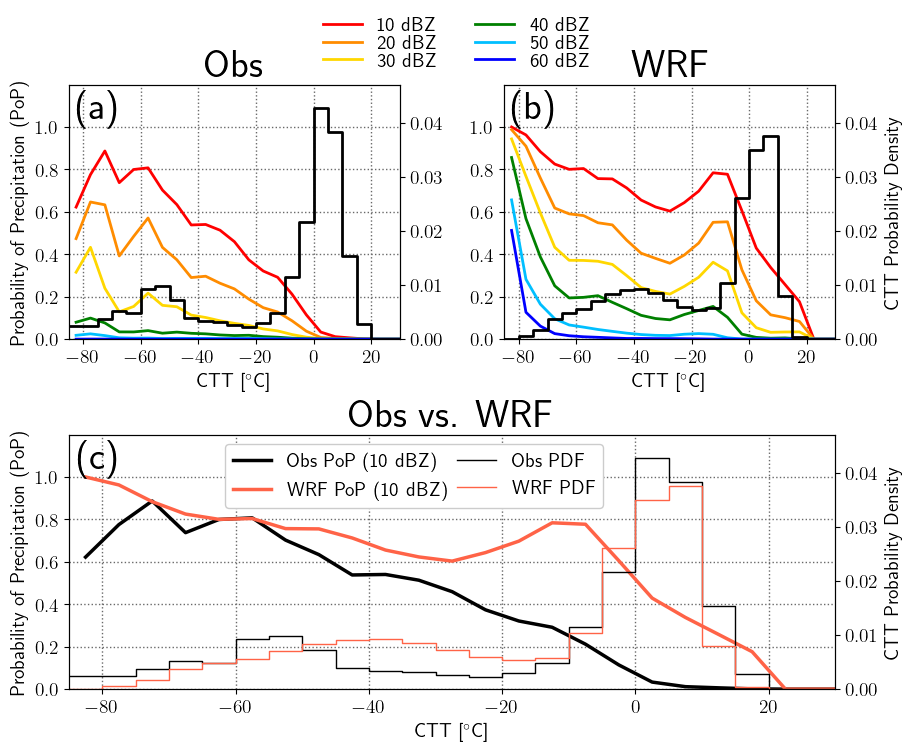

done


In [16]:
# --- Assume you have your DataFrames loaded ---
# df_plot_obs, df_plot_wrf_ir

# --- Define Settings ---
Fontsize = 14
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-85, 45, 5)

colors = ['red','darkorange','gold','green','deepskyblue','blue']

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[1, :])   # Bottom, spanning all columns

# --- 2. Panel 1: OBS CTT --- (Unchanged)
obs_stats_ctt = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax1.plot(obs_stats_ctt['bin_centers'], obs_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i], label=f'{thresh} dBZ')
ax1.set_title('Obs', fontsize=Fontsize*2)
ax_hist1 = ax1.twinx()
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='k', lw=2)

# --- 3. Panel 2: WRF CTT --- (Unchanged)
wrf_stats_ctt = calculate_binned_stats(df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax2.plot(wrf_stats_ctt['bin_centers'], wrf_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i]) # No label needed here
ax2.set_title('WRF', fontsize=Fontsize*2)
ax_hist2 = ax2.twinx()
plot_pdf(ax_hist2, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, color='k', lw=2)

# ======================================================================
# --- 4. Panel 3: OBS vs WRF CTT Comparison (CORRECTED) ---
# ======================================================================
ax3.set_title('Obs vs. WRF', fontsize=Fontsize*2)
ax_hist3 = ax3.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, ref_thresh_single)

ax3.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax3.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist3, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist3, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, color='tomato', lw=1, linestyle='solid', label='WRF PDF')

# ======================================================================
# --- 5. Final Formatting and Labels (CORRECTED) ---
# ======================================================================
# Panel labels (a, b, c)
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax3.text(0.01, 0.98, '(c)', transform=ax3.transAxes, ha='left', va='top', fontsize=Fontsize*2)

# Axis labels
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax3.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist2.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax_hist3.set_ylabel('CTT Probability Density', fontsize=Fontsize) # Changed from CTH
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax3.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize) # Changed from CTH

# Ticks, limits, and grids
for ax in [ax1, ax2, ax3]:
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylim(0, 1.05)
ax1.set_xlim(-85, 30); ax2.set_xlim(-85, 30)
ax3.set_xlim(-85, 30) # Changed from CTH limits, removed invert_xaxis()

for ax_hist in [ax_hist1, ax_hist2, ax_hist3]:
    ax_hist.tick_params(labelsize=Fontsize)

# --- 6. Legends --- (Unchanged)
if False:
    fig.legend(handles=ax1.get_legend_handles_labels()[0], 
               labels=ax1.get_legend_handles_labels()[1], 
               fontsize=Fontsize, framealpha=False,
               bbox_to_anchor=(0.5, 0.94), loc='lower center', ncol=2,labelspacing=0.01)

if True:
    fig.legend(handles=ax1.get_legend_handles_labels()[0], 
               labels=ax1.get_legend_handles_labels()[1], 
               fontsize=Fontsize, framealpha=False,
               bbox_to_anchor=(0.5, 0.94), loc='lower center', ncol=2,labelspacing=0.01)

# ==========================================================
# === NEW: Unified legend for the bottom panel ===
# ==========================================================
# 1. Get handles and labels from both axes
handles_main, labels_main = ax3.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist3.get_legend_handles_labels()

# 2. Combine them into single lists
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

# 3. Create a single, unified legend on one of the axes
#    `ncol=2` helps organize the four legend items.
ax3.legend(all_handles, all_labels, loc='upper center', fontsize=Fontsize, ncol=2,columnspacing=0.5,bbox_to_anchor=(0.45,1.),framealpha=1)
# ==========================================================


# Get the maximum y-limit from the two top histogram axes
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1])

# Set both axes to this new, shared limit for direct comparison
# We add a little padding (e.g., 5%) for better aesthetics
ax_hist1.set_ylim(0, max_pdf_y * 1.05)
ax_hist2.set_ylim(0, max_pdf_y * 1.05)
ax_hist3.set_ylim(0, max_pdf_y * 1.05)

ax1.set_ylim(0,1.2)
ax2.set_ylim(0,1.2)
ax3.set_ylim(0,1.2)

ax1.set_yticks(np.arange(0,1.2,0.2))
ax2.set_yticks(np.arange(0,1.2,0.2))
ax3.set_yticks(np.arange(0,1.2,0.2))

ax1.set_xticks(np.arange(-80,40,20))
ax2.set_xticks(np.arange(-80,40,20))
ax3.set_xticks(np.arange(-80,40,20))

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_IR.png'
#plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
plt.show()
plt.close()
print('done')

In [51]:

# --- Define Settings ---
Fontsize = 14
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] 
ctt_bins = np.arange(-85, 45, 5)

# --- THIS IS THE KEY CHANGE ---
# 1. REMOVE the hard-coded colors list
# colors = ['red','darkorange','gold','green','deepskyblue','blue'] # This is deleted

# 2. CHOOSE a colormap and create a list of colors from it
num_colors = len(ref_threshes_all)
# 'viridis', 'plasma', 'cividis', or 'inferno' are all excellent choices.
cmap = plt.colormaps['plasma'] 
colors = [cmap(i) for i in np.linspace(0, 1, num_colors)]
# --- END OF CHANGE ---

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[1, :])   # Bottom, spanning all columns

# --- 2. Panel 1: OBS CTT --- 
# The plotting call now correctly uses the new `colors` list.
obs_stats_ctt = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax1.plot(obs_stats_ctt['bin_centers'], obs_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i], label=f'{thresh} dBZ')
ax1.set_title('Obs', fontsize=Fontsize*2)
ax_hist1 = ax1.twinx()
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='k', lw=1.5,ls='dashed')

# --- 3. Panel 2: WRF CTT --- 
# This also uses the new `colors` list.
wrf_stats_ctt = calculate_binned_stats(df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax2.plot(wrf_stats_ctt['bin_centers'], wrf_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i])
ax2.set_title('WRF', fontsize=Fontsize*2)
ax_hist2 = ax2.twinx()
plot_pdf(ax_hist2, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, color='tomato', lw=1.5,ls='dashed')

# --- 4. Panel 3: OBS vs WRF CTT Comparison ---
# (This panel is unchanged as it doesn't use the multi-color list)
ax3.set_title('Obs vs. WRF', fontsize=Fontsize*2)
ax_hist3 = ax3.twinx()
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, ref_thresh_single)
ax3.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax3.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')
plot_pdf(ax_hist3, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1.5, linestyle='dashed', label='Obs CTT PDF')
plot_pdf(ax_hist3, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, color='tomato', lw=1.5, linestyle='dashed', label='WRF CTT PDF')

# --- 5. Final Formatting and Labels ---
# (This section is unchanged)
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax3.text(0.01, 0.98, '(c)', transform=ax3.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax3.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist2.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax_hist3.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax3.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
for ax in [ax1, ax2, ax3]:
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylim(0, 1.05)
ax1.set_xlim(-85, 30); ax2.set_xlim(-85, 30)
ax3.set_xlim(-85, 30)
for ax_hist in [ax_hist1, ax_hist2, ax_hist3]:
    ax_hist.tick_params(labelsize=Fontsize)

# --- 6. Legends ---
# Your logic for creating the legends is complex but correct and is left unchanged.
handles_top, labels_top = ax1.get_legend_handles_labels()
fig.legend(handles=handles_top,
           labels=labels_top,
           fontsize=Fontsize, framealpha=False,
           bbox_to_anchor=(0.5, 0.94), loc='lower center', ncol=2, labelspacing=0.01)

custom_line_obs = [Line2D([0], [0], color='k',ls='dashed',lw=2)]
custom_line_wrf = [Line2D([0], [0], color='tomato',ls='dashed',lw=2)]
ax_hist1.legend(custom_line_obs, ['Obs CTT PDF'],fontsize=Fontsize*0.9,loc='upper center',bbox_to_anchor=(0.425,0.95),framealpha=1,edgecolor='k')
ax_hist2.legend(custom_line_wrf, ['WRF CTT PDF'],fontsize=Fontsize*0.9,loc='upper center',bbox_to_anchor=(0.45,0.95),framealpha=1,edgecolor='k')

handles_main, labels_main = ax3.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist3.get_legend_handles_labels()
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin
ax3.legend(all_handles, all_labels, loc='upper center', fontsize=Fontsize*0.9, ncol=2,columnspacing=0.5,bbox_to_anchor=(0.45,1.),framealpha=1)

# --- 7. Axis Limit Synchronization ---
# (This section is unchanged)
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1])
ax_hist1.set_ylim(0, max_pdf_y * 1.05)
ax_hist2.set_ylim(0, max_pdf_y * 1.05)
ax_hist3.set_ylim(0, max_pdf_y * 1.05)
ax1.set_ylim(0,1.2); ax2.set_ylim(0,1.2); ax3.set_ylim(0,1.2)
ax1.set_yticks(np.arange(0,1.2,0.2)); ax2.set_yticks(np.arange(0,1.2,0.2)); ax3.set_yticks(np.arange(0,1.2,0.2))
ax1.set_xticks(np.arange(-80,40,20)); ax2.set_xticks(np.arange(-80,40,20)); ax3.set_xticks(np.arange(-80,40,20))

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_IR.png'
plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


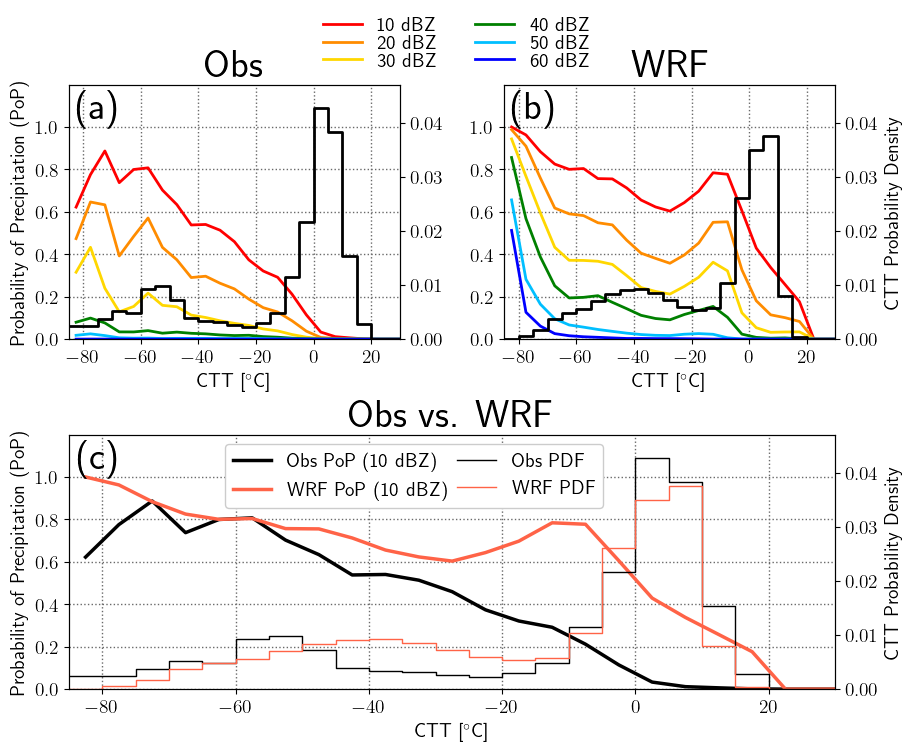

done


In [48]:
# --- Assume you have your DataFrames loaded ---
# df_plot_obs, df_plot_wrf_ir

# --- Define Settings ---
Fontsize = 14
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-85, 45, 5)

colors = ['red','darkorange','gold','green','deepskyblue','blue']

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[1, :])   # Bottom, spanning all columns

# --- 2. Panel 1: OBS CTT --- (Unchanged)
obs_stats_ctt = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax1.plot(obs_stats_ctt['bin_centers'], obs_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i], label=f'{thresh} dBZ')
ax1.set_title('Obs', fontsize=Fontsize*2)
ax_hist1 = ax1.twinx()
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='k', lw=2)

# --- 3. Panel 2: WRF CTT --- (Unchanged)
wrf_stats_ctt = calculate_binned_stats(df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax2.plot(wrf_stats_ctt['bin_centers'], wrf_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i]) # No label needed here
ax2.set_title('WRF', fontsize=Fontsize*2)
ax_hist2 = ax2.twinx()
plot_pdf(ax_hist2, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, color='k', lw=2)

# ======================================================================
# --- 4. Panel 3: OBS vs WRF CTT Comparison (CORRECTED) ---
# ======================================================================
ax3.set_title('Obs vs. WRF', fontsize=Fontsize*2)
ax_hist3 = ax3.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, ref_thresh_single)

ax3.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax3.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist3, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist3, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, color='tomato', lw=1, linestyle='solid', label='WRF PDF')

# ======================================================================
# --- 5. Final Formatting and Labels (CORRECTED) ---
# ======================================================================
# Panel labels (a, b, c)
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax3.text(0.01, 0.98, '(c)', transform=ax3.transAxes, ha='left', va='top', fontsize=Fontsize*2)

# Axis labels
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax3.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist2.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax_hist3.set_ylabel('CTT Probability Density', fontsize=Fontsize) # Changed from CTH
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax3.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize) # Changed from CTH

# Ticks, limits, and grids
for ax in [ax1, ax2, ax3]:
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylim(0, 1.05)
ax1.set_xlim(-85, 30); ax2.set_xlim(-85, 30)
ax3.set_xlim(-85, 30) # Changed from CTH limits, removed invert_xaxis()

for ax_hist in [ax_hist1, ax_hist2, ax_hist3]:
    ax_hist.tick_params(labelsize=Fontsize)

# --- 6. Legends --- (Unchanged)
if False:
    fig.legend(handles=ax1.get_legend_handles_labels()[0], 
               labels=ax1.get_legend_handles_labels()[1], 
               fontsize=Fontsize, framealpha=False,
               bbox_to_anchor=(0.5, 0.94), loc='lower center', ncol=2,labelspacing=0.01)

if True:
    fig.legend(handles=ax1.get_legend_handles_labels()[0], 
               labels=ax1.get_legend_handles_labels()[1], 
               fontsize=Fontsize, framealpha=False,
               bbox_to_anchor=(0.5, 0.94), loc='lower center', ncol=2,labelspacing=0.01)

# ==========================================================
# === NEW: Unified legend for the bottom panel ===
# ==========================================================
# 1. Get handles and labels from both axes
handles_main, labels_main = ax3.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist3.get_legend_handles_labels()

# 2. Combine them into single lists
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

# 3. Create a single, unified legend on one of the axes
#    `ncol=2` helps organize the four legend items.
ax3.legend(all_handles, all_labels, loc='upper center', fontsize=Fontsize, ncol=2,columnspacing=0.5,bbox_to_anchor=(0.45,1.),framealpha=1)
# ==========================================================


# Get the maximum y-limit from the two top histogram axes
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1])

# Set both axes to this new, shared limit for direct comparison
# We add a little padding (e.g., 5%) for better aesthetics
ax_hist1.set_ylim(0, max_pdf_y * 1.05)
ax_hist2.set_ylim(0, max_pdf_y * 1.05)
ax_hist3.set_ylim(0, max_pdf_y * 1.05)

ax1.set_ylim(0,1.2)
ax2.set_ylim(0,1.2)
ax3.set_ylim(0,1.2)

ax1.set_yticks(np.arange(0,1.2,0.2))
ax2.set_yticks(np.arange(0,1.2,0.2))
ax3.set_yticks(np.arange(0,1.2,0.2))

ax1.set_xticks(np.arange(-80,40,20))
ax2.set_xticks(np.arange(-80,40,20))
ax3.set_xticks(np.arange(-80,40,20))

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_IR.png'
#plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
plt.show()
plt.close()
print('done')

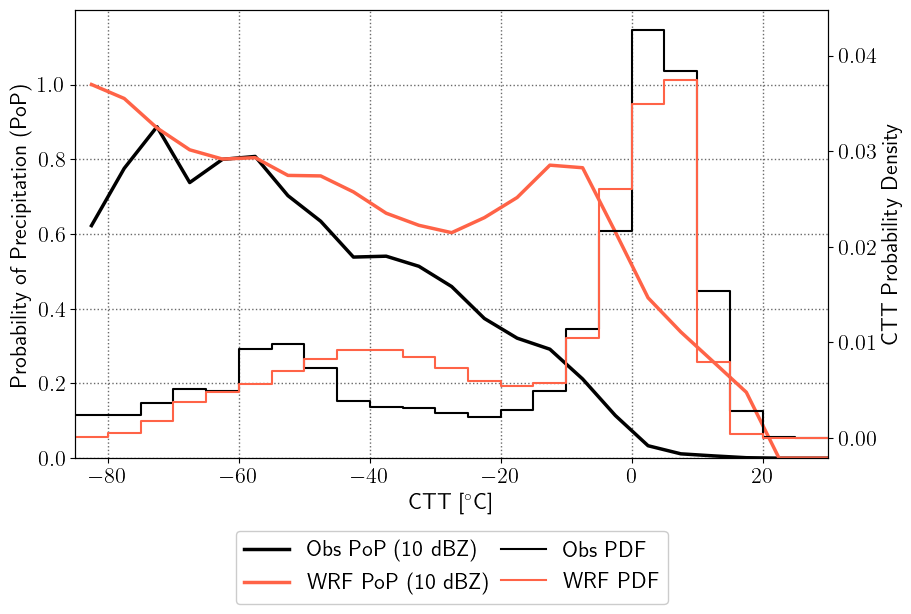

done


In [14]:
# --- Assume you have your DataFrames loaded ---
# df_plot_obs, df_plot_wrf_ir

# --- Define Settings ---
Fontsize = 16
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-85, 45, 5)

colors = ['red','darkorange','gold','green','deepskyblue','blue']

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(9, 6), constrained_layout=True)
gs = GridSpec(1, 1, figure=fig)

ax1 = fig.add_subplot(gs[0])  # Top-left


# ======================================================================
# --- 4. Panel 3: OBS vs WRF CTT Comparison (CORRECTED) ---
# ======================================================================
#ax1.set_title('Obs vs. WRF', fontsize=Fontsize*2)
ax_hist1 = ax1.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, ref_thresh_single)

ax1.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax1.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1.5, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist1, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, color='tomato', lw=1.5, linestyle='solid', label='WRF PDF')


# Axis labels
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist1.set_ylabel('CTT Probability Density', fontsize=Fontsize) # Changed from CTH
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize) # Changed from CTH

ax1.grid(which='both', lw=1, ls='dotted', c='dimgrey')
ax1.tick_params(labelsize=Fontsize)
ax1.set_ylim(0, 1.01)
ax1.set_xlim(-85, 30) # Changed from CTH limits, removed invert_xaxis()
ax_hist1.tick_params(labelsize=Fontsize)

handles_main, labels_main = ax1.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist1.get_legend_handles_labels()

# 2. Combine them into single lists
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

# 3. Create a single, unified legend on one of the axes
#    `ncol=2` helps organize the four legend items.
#ax1.legend(all_handles, all_labels, loc='upper center', fontsize=Fontsize, ncol=2,columnspacing=0.5,bbox_to_anchor=(0.35,1.),framealpha=1)
ax1.legend(all_handles, all_labels, loc='lower center', fontsize=Fontsize, ncol=2,columnspacing=0.5,bbox_to_anchor=(0.5,-0.35),framealpha=1)
ax1.set_ylim(0,1.2)
ax1.set_yticks(np.arange(0,1.2,0.2))
ax1.set_xticks(np.arange(-80,40,20))

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_IR_compare_only.png'
#plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
plt.show()
plt.close()
print('done')

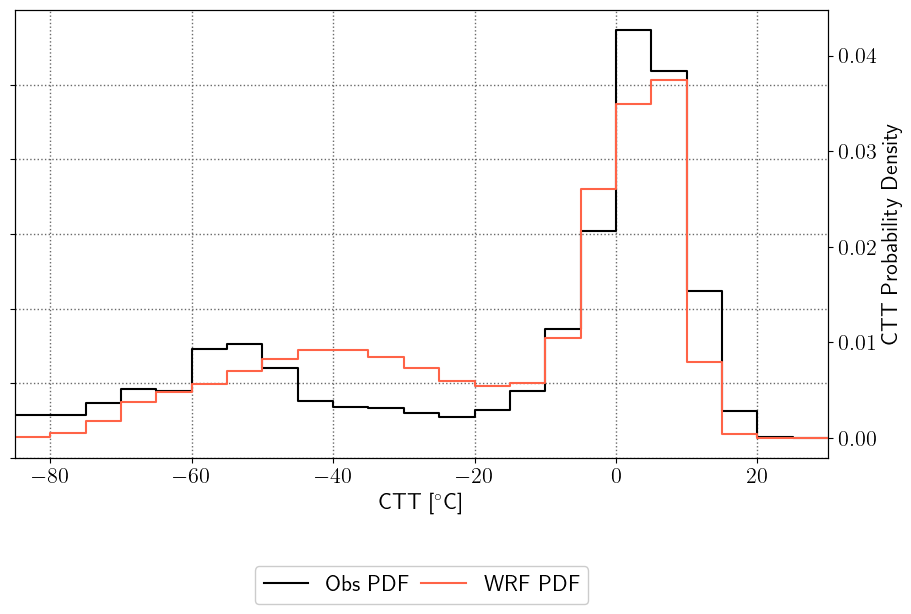

In [20]:
# --- Assume you have your DataFrames loaded ---
# df_plot_obs, df_plot_wrf_ir

# --- Define Settings ---
Fontsize = 16
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-85, 45, 5)

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(9, 6), constrained_layout=True)
gs = GridSpec(1, 1, figure=fig)

ax1 = fig.add_subplot(gs[0])  # Top-left


# ======================================================================
# --- 4. Panel 3: OBS vs WRF CTT Comparison (CORRECTED) ---
# ======================================================================
#ax1.set_title('Obs vs. WRF', fontsize=Fontsize*2)
ax_hist1 = ax1.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, ref_thresh_single)

#ax1.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
#         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
#ax1.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
#         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1.5, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist1, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, color='tomato', lw=1.5, linestyle='solid', label='WRF PDF')


# Axis labels
#ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist1.set_ylabel('CTT Probability Density', fontsize=Fontsize) # Changed from CTH
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize) # Changed from CTH

ax1.grid(which='both', lw=1, ls='dotted', c='dimgrey')
ax1.tick_params(labelsize=Fontsize)
ax1.set_ylim(0, 1.01)
ax1.set_xlim(-85, 30) # Changed from CTH limits, removed invert_xaxis()
ax_hist1.tick_params(labelsize=Fontsize)
ax1.set_yticks([])
ax1.set_yticklabels([])
handles_main, labels_main = ax1.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist1.get_legend_handles_labels()

# 2. Combine them into single lists
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

ax1.legend(all_handles, all_labels, loc='lower center', fontsize=Fontsize, ncol=2,columnspacing=0.5,bbox_to_anchor=(0.5,-0.35),framealpha=1)
ax1.set_ylim(0,1.2)
ax1.set_yticks(np.arange(0,1.2,0.2))
ax1.set_xticks(np.arange(-80,40,20))

plt.show()
plt.close()

# VIS CTT

In [42]:
# --- Assume you have your DataFrames loaded ---
# df_plot_obs, df_plot_wrf_ir

# --- Define Settings ---
Fontsize = 14
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-85, 45, 5)

colors = ['red','darkorange','gold','green','deepskyblue','blue']

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[1, :])   # Bottom, spanning all columns

# --- 2. Panel 1: OBS CTT --- (Unchanged)
obs_stats_ctt = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax1.plot(obs_stats_ctt['bin_centers'], obs_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i], label=f'{thresh} dBZ')
ax1.set_title('Obs', fontsize=Fontsize*2)
ax_hist1 = ax1.twinx()
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='k', lw=2)

# --- 3. Panel 2: WRF CTT --- (Unchanged)
wrf_stats_ctt = calculate_binned_stats(df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax2.plot(wrf_stats_ctt['bin_centers'], wrf_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i]) # No label needed here
ax2.set_title('WRF', fontsize=Fontsize*2)
ax_hist2 = ax2.twinx()
plot_pdf(ax_hist2, df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, color='k', lw=2)

# ======================================================================
# --- 4. Panel 3: OBS vs WRF CTT Comparison (CORRECTED) ---
# ======================================================================
ax3.set_title('Obs vs. WRF', fontsize=Fontsize*2)
ax_hist3 = ax3.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, ref_thresh_single)

ax3.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax3.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist3, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist3, df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, color='tomato', lw=1, linestyle='solid', label='WRF PDF')

# ======================================================================
# --- 5. Final Formatting and Labels (CORRECTED) ---
# ======================================================================
# Panel labels (a, b, c)
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax3.text(0.01, 0.98, '(c)', transform=ax3.transAxes, ha='left', va='top', fontsize=Fontsize*2)

# Axis labels
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax3.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist2.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax_hist3.set_ylabel('CTT Probability Density', fontsize=Fontsize) # Changed from CTH
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax3.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize) # Changed from CTH

# Ticks, limits, and grids
for ax in [ax1, ax2, ax3]:
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylim(0, 1.05)
ax1.set_xlim(-85, 30); ax2.set_xlim(-85, 30)
ax3.set_xlim(-85, 30) # Changed from CTH limits, removed invert_xaxis()

for ax_hist in [ax_hist1, ax_hist2, ax_hist3]:
    ax_hist.tick_params(labelsize=Fontsize)

# --- 6. Legends --- (Unchanged)
fig.legend(handles=ax1.get_legend_handles_labels()[0], 
           labels=ax1.get_legend_handles_labels()[1], 
           fontsize=Fontsize, framealpha=False,
           bbox_to_anchor=(0.5, 0.94), loc='lower center', ncol=2,labelspacing=0.01)

# ==========================================================
# === NEW: Unified legend for the bottom panel ===
# ==========================================================
# 1. Get handles and labels from both axes
handles_main, labels_main = ax3.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist3.get_legend_handles_labels()

# 2. Combine them into single lists
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

# 3. Create a single, unified legend on one of the axes
#    `ncol=2` helps organize the four legend items.
ax3.legend(all_handles, all_labels, loc='upper center', fontsize=Fontsize, ncol=2,columnspacing=0.5,bbox_to_anchor=(0.45,1.),framealpha=1)
# ==========================================================


# Get the maximum y-limit from the two top histogram axes
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1])

# Set both axes to this new, shared limit for direct comparison
# We add a little padding (e.g., 5%) for better aesthetics
ax_hist1.set_ylim(0, max_pdf_y * 1.05)
ax_hist2.set_ylim(0, max_pdf_y * 1.05)
ax_hist3.set_ylim(0, max_pdf_y * 1.05)

ax1.set_ylim(0,1.2)
ax2.set_ylim(0,1.2)
ax3.set_ylim(0,1.2)

ax1.set_yticks(np.arange(0,1.2,0.2))
ax2.set_yticks(np.arange(0,1.2,0.2))
ax3.set_yticks(np.arange(0,1.2,0.2))

ax1.set_xticks(np.arange(-80,40,20))
ax2.set_xticks(np.arange(-80,40,20))
ax3.set_xticks(np.arange(-80,40,20))

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_VIS.png'
plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


In [54]:

# --- Define Settings ---
Fontsize = 14
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] 
ctt_bins = np.arange(-85, 45, 5)

# --- THIS IS THE KEY CHANGE ---
# 1. REMOVE the hard-coded colors list
# colors = ['red','darkorange','gold','green','deepskyblue','blue'] # This is deleted

# 2. CHOOSE a colormap and create a list of colors from it
num_colors = len(ref_threshes_all)
# 'viridis', 'plasma', 'cividis', or 'inferno' are all excellent choices.
cmap = plt.colormaps['plasma'] 
colors = [cmap(i) for i in np.linspace(0, 1, num_colors)]
# --- END OF CHANGE ---

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[1, :])   # Bottom, spanning all columns

# --- 2. Panel 1: OBS CTT --- 
# The plotting call now correctly uses the new `colors` list.
obs_stats_ctt = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax1.plot(obs_stats_ctt['bin_centers'], obs_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i], label=f'{thresh} dBZ')
ax1.set_title('Obs', fontsize=Fontsize*2)
ax_hist1 = ax1.twinx()
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='k', lw=1.5,ls='dashed')

# --- 3. Panel 2: WRF CTT --- 
# This also uses the new `colors` list.
wrf_stats_ctt = calculate_binned_stats(df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax2.plot(wrf_stats_ctt['bin_centers'], wrf_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i])
ax2.set_title('WRF', fontsize=Fontsize*2)
ax_hist2 = ax2.twinx()
plot_pdf(ax_hist2, df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, color='tomato', lw=1.5,ls='dashed')

# --- 4. Panel 3: OBS vs WRF CTT Comparison ---
# (This panel is unchanged as it doesn't use the multi-color list)
ax3.set_title('Obs vs. WRF', fontsize=Fontsize*2)
ax_hist3 = ax3.twinx()
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, ref_thresh_single)
ax3.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax3.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')
plot_pdf(ax_hist3, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1.5, linestyle='dashed', label='Obs CTT PDF')
plot_pdf(ax_hist3, df_plot_wrf_vis, 'ctt_tau_vis', ctt_bins, color='tomato', lw=1.5, linestyle='dashed', label='WRF CTT PDF')

# --- 5. Final Formatting and Labels ---
# (This section is unchanged)
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax3.text(0.01, 0.98, '(c)', transform=ax3.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax3.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist2.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax_hist3.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax3.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
for ax in [ax1, ax2, ax3]:
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylim(0, 1.05)
ax1.set_xlim(-85, 30); ax2.set_xlim(-85, 30)
ax3.set_xlim(-85, 30)
for ax_hist in [ax_hist1, ax_hist2, ax_hist3]:
    ax_hist.tick_params(labelsize=Fontsize)

# --- 6. Legends ---
# Your logic for creating the legends is complex but correct and is left unchanged.
handles_top, labels_top = ax1.get_legend_handles_labels()
fig.legend(handles=handles_top,
           labels=labels_top,
           fontsize=Fontsize, framealpha=False,
           bbox_to_anchor=(0.5, 0.94), loc='lower center', ncol=2, labelspacing=0.01)

custom_line_obs = [Line2D([0], [0], color='k',ls='dashed',lw=2)]
custom_line_wrf = [Line2D([0], [0], color='tomato',ls='dashed',lw=2)]
ax_hist1.legend(custom_line_obs, ['Obs CTT PDF'],fontsize=Fontsize*0.9,loc='upper center',bbox_to_anchor=(0.425,0.95),framealpha=1,edgecolor='k')
ax_hist2.legend(custom_line_wrf, ['WRF CTT PDF'],fontsize=Fontsize*0.9,loc='upper center',bbox_to_anchor=(0.45,0.95),framealpha=1,edgecolor='k')

handles_main, labels_main = ax3.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist3.get_legend_handles_labels()
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin
ax3.legend(all_handles, all_labels, loc='upper center', fontsize=Fontsize*0.9, ncol=2,columnspacing=0.5,bbox_to_anchor=(0.45,1.),framealpha=1)

# --- 7. Axis Limit Synchronization ---
# (This section is unchanged)
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1])
ax_hist1.set_ylim(0, max_pdf_y * 1.05)
ax_hist2.set_ylim(0, max_pdf_y * 1.05)
ax_hist3.set_ylim(0, max_pdf_y * 1.05)
ax1.set_ylim(0,1.2); ax2.set_ylim(0,1.2); ax3.set_ylim(0,1.2)
ax1.set_yticks(np.arange(0,1.2,0.2)); ax2.set_yticks(np.arange(0,1.2,0.2)); ax3.set_yticks(np.arange(0,1.2,0.2))
ax1.set_xticks(np.arange(-80,40,20)); ax2.set_xticks(np.arange(-80,40,20)); ax3.set_xticks(np.arange(-80,40,20))

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_VIS.png'
plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


# VIS:IR 50:50

In [43]:
# --- Assume you have your DataFrames loaded ---
# df_plot_obs, df_plot_wrf_ir

# --- Define Settings ---
Fontsize = 14
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-85, 45, 5)

colors = ['red','darkorange','gold','green','deepskyblue','blue']

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[1, :])   # Bottom, spanning all columns

# --- 2. Panel 1: OBS CTT --- (Unchanged)
obs_stats_ctt = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax1.plot(obs_stats_ctt['bin_centers'], obs_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i], label=f'{thresh} dBZ')
ax1.set_title('Obs', fontsize=Fontsize*2)
ax_hist1 = ax1.twinx()
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='k', lw=2)

# --- 3. Panel 2: WRF CTT --- (Unchanged)
wrf_stats_ctt = calculate_binned_stats(df_plot_wrf_visir5050, 'ctt_tau_50_50', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax2.plot(wrf_stats_ctt['bin_centers'], wrf_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i]) # No label needed here
ax2.set_title('WRF', fontsize=Fontsize*2)
ax_hist2 = ax2.twinx()
plot_pdf(ax_hist2, df_plot_wrf_visir5050, 'ctt_tau_50_50', ctt_bins, color='k', lw=2)

# ======================================================================
# --- 4. Panel 3: OBS vs WRF CTT Comparison (CORRECTED) ---
# ======================================================================
ax3.set_title('Obs vs. WRF', fontsize=Fontsize*2)
ax_hist3 = ax3.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_visir5050, 'ctt_tau_50_50', ctt_bins, ref_thresh_single)

ax3.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax3.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist3, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist3, df_plot_wrf_visir5050, 'ctt_tau_50_50', ctt_bins, color='tomato', lw=1, linestyle='solid', label='WRF PDF')

# ======================================================================
# --- 5. Final Formatting and Labels (CORRECTED) ---
# ======================================================================
# Panel labels (a, b, c)
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax3.text(0.01, 0.98, '(c)', transform=ax3.transAxes, ha='left', va='top', fontsize=Fontsize*2)

# Axis labels
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax3.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist2.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax_hist3.set_ylabel('CTT Probability Density', fontsize=Fontsize) # Changed from CTH
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax3.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize) # Changed from CTH

# Ticks, limits, and grids
for ax in [ax1, ax2, ax3]:
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylim(0, 1.05)
ax1.set_xlim(-85, 30); ax2.set_xlim(-85, 30)
ax3.set_xlim(-85, 30) # Changed from CTH limits, removed invert_xaxis()

for ax_hist in [ax_hist1, ax_hist2, ax_hist3]:
    ax_hist.tick_params(labelsize=Fontsize)

# --- 6. Legends --- (Unchanged)
fig.legend(handles=ax1.get_legend_handles_labels()[0], 
           labels=ax1.get_legend_handles_labels()[1], 
           fontsize=Fontsize, framealpha=False,
           bbox_to_anchor=(0.5, 0.94), loc='lower center', ncol=2,labelspacing=0.01)

# ==========================================================
# === NEW: Unified legend for the bottom panel ===
# ==========================================================
# 1. Get handles and labels from both axes
handles_main, labels_main = ax3.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist3.get_legend_handles_labels()

# 2. Combine them into single lists
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

# 3. Create a single, unified legend on one of the axes
#    `ncol=2` helps organize the four legend items.
ax3.legend(all_handles, all_labels, loc='upper center', fontsize=Fontsize, ncol=2,columnspacing=0.5,bbox_to_anchor=(0.45,1.),framealpha=1)
# ==========================================================


# Get the maximum y-limit from the two top histogram axes
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1])

# Set both axes to this new, shared limit for direct comparison
# We add a little padding (e.g., 5%) for better aesthetics
ax_hist1.set_ylim(0, max_pdf_y * 1.05)
ax_hist2.set_ylim(0, max_pdf_y * 1.05)
ax_hist3.set_ylim(0, max_pdf_y * 1.05)

ax1.set_ylim(0,1.2)
ax2.set_ylim(0,1.2)
ax3.set_ylim(0,1.2)

ax1.set_yticks(np.arange(0,1.2,0.2))
ax2.set_yticks(np.arange(0,1.2,0.2))
ax3.set_yticks(np.arange(0,1.2,0.2))

ax1.set_xticks(np.arange(-80,40,20))
ax2.set_xticks(np.arange(-80,40,20))
ax3.set_xticks(np.arange(-80,40,20))

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_VISIR5050.png'
plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


In [56]:

# --- Define Settings ---
Fontsize = 14
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] 
ctt_bins = np.arange(-85, 45, 5)

# --- THIS IS THE KEY CHANGE ---
# 1. REMOVE the hard-coded colors list
# colors = ['red','darkorange','gold','green','deepskyblue','blue'] # This is deleted

# 2. CHOOSE a colormap and create a list of colors from it
num_colors = len(ref_threshes_all)
# 'viridis', 'plasma', 'cividis', or 'inferno' are all excellent choices.
cmap = plt.colormaps['plasma'] 
colors = [cmap(i) for i in np.linspace(0, 1, num_colors)]
# --- END OF CHANGE ---

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])  # Top-left
ax2 = fig.add_subplot(gs[0, 1])  # Top-right
ax3 = fig.add_subplot(gs[1, :])   # Bottom, spanning all columns

# --- 2. Panel 1: OBS CTT --- 
# The plotting call now correctly uses the new `colors` list.
obs_stats_ctt = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax1.plot(obs_stats_ctt['bin_centers'], obs_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i], label=f'{thresh} dBZ')
ax1.set_title('Obs', fontsize=Fontsize*2)
ax_hist1 = ax1.twinx()
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='k', lw=1.5,ls='dashed')

# --- 3. Panel 2: WRF CTT --- 
# This also uses the new `colors` list.
wrf_stats_ctt = calculate_binned_stats(df_plot_wrf_visir5050, 'ctt_tau_50_50', ctt_bins, ref_threshes_all)
for i, thresh in enumerate(ref_threshes_all):
    ax2.plot(wrf_stats_ctt['bin_centers'], wrf_stats_ctt[f'prob_{thresh}'],
             lw=2, c=colors[i])
ax2.set_title('WRF', fontsize=Fontsize*2)
ax_hist2 = ax2.twinx()
plot_pdf(ax_hist2, df_plot_wrf_visir5050, 'ctt_tau_50_50', ctt_bins, color='tomato', lw=1.5,ls='dashed')

# --- 4. Panel 3: OBS vs WRF CTT Comparison ---
# (This panel is unchanged as it doesn't use the multi-color list)
ax3.set_title('Obs vs. WRF', fontsize=Fontsize*2)
ax_hist3 = ax3.twinx()
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_visir5050, 'ctt_tau_vis', ctt_bins, ref_thresh_single)
ax3.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs PoP (10 dBZ)')
ax3.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF PoP (10 dBZ)')
plot_pdf(ax_hist3, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1.5, linestyle='dashed', label='Obs CTT PDF')
plot_pdf(ax_hist3, df_plot_wrf_visir5050, 'ctt_tau_50_50', ctt_bins, color='tomato', lw=1.5, linestyle='dashed', label='WRF CTT PDF')

# --- 5. Final Formatting and Labels ---
# (This section is unchanged)
ax1.text(0.02, 0.98, '(a)', transform=ax1.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax2.text(0.02, 0.98, '(b)', transform=ax2.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax3.text(0.01, 0.98, '(c)', transform=ax3.transAxes, ha='left', va='top', fontsize=Fontsize*2)
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax3.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist2.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax_hist3.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax3.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
for ax in [ax1, ax2, ax3]:
    ax.grid(which='both', lw=1, ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylim(0, 1.05)
ax1.set_xlim(-85, 30); ax2.set_xlim(-85, 30)
ax3.set_xlim(-85, 30)
for ax_hist in [ax_hist1, ax_hist2, ax_hist3]:
    ax_hist.tick_params(labelsize=Fontsize)

# --- 6. Legends ---
# Your logic for creating the legends is complex but correct and is left unchanged.
handles_top, labels_top = ax1.get_legend_handles_labels()
fig.legend(handles=handles_top,
           labels=labels_top,
           fontsize=Fontsize, framealpha=False,
           bbox_to_anchor=(0.5, 0.94), loc='lower center', ncol=2, labelspacing=0.01)

custom_line_obs = [Line2D([0], [0], color='k',ls='dashed',lw=2)]
custom_line_wrf = [Line2D([0], [0], color='tomato',ls='dashed',lw=2)]
ax_hist1.legend(custom_line_obs, ['Obs CTT PDF'],fontsize=Fontsize*0.9,loc='upper center',bbox_to_anchor=(0.425,0.95),framealpha=1,edgecolor='k')
ax_hist2.legend(custom_line_wrf, ['WRF CTT PDF'],fontsize=Fontsize*0.9,loc='upper center',bbox_to_anchor=(0.45,0.95),framealpha=1,edgecolor='k')

handles_main, labels_main = ax3.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist3.get_legend_handles_labels()
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin
ax3.legend(all_handles, all_labels, loc='upper center', fontsize=Fontsize*0.9, ncol=2,columnspacing=0.5,bbox_to_anchor=(0.45,1.),framealpha=1)

# --- 7. Axis Limit Synchronization ---
# (This section is unchanged)
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1])
ax_hist1.set_ylim(0, max_pdf_y * 1.05)
ax_hist2.set_ylim(0, max_pdf_y * 1.05)
ax_hist3.set_ylim(0, max_pdf_y * 1.05)
ax1.set_ylim(0,1.2); ax2.set_ylim(0,1.2); ax3.set_ylim(0,1.2)
ax1.set_yticks(np.arange(0,1.2,0.2)); ax2.set_yticks(np.arange(0,1.2,0.2)); ax3.set_yticks(np.arange(0,1.2,0.2))
ax1.set_xticks(np.arange(-80,40,20)); ax2.set_xticks(np.arange(-80,40,20)); ax3.set_xticks(np.arange(-80,40,20))

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_VISIR5050.png'
plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done


## Figure for Adam that shows only comparisons on both linear and logarithmic axes

In [44]:
plt.rcParams['text.usetex'] = False

In [70]:
# --- Assume you have your DataFrames loaded ---
# df_plot_obs, df_plot_wrf_ir

# --- Define Settings ---
Fontsize = 13
ref_threshes_all = np.arange(10, 70, 10)
ref_thresh_single = [10] # For the comparison plot

ctt_bins = np.arange(-85, 45, 5)

colors = ['red','darkorange','gold','green','deepskyblue','blue']

# --- 1. Create the Figure and GridSpec Layout ---
fig = plt.figure(figsize=(11, 3.5), constrained_layout=True)
gs = GridSpec(1, 2, figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

ax_hist1 = ax1.twinx()
ax_hist2 = ax2.twinx()

# Calculate stats (only for 10 dBZ) for CTT and plot PoP lines
obs_stats_ctt_comp = calculate_binned_stats(df_plot_obs, 'ctt', ctt_bins, ref_thresh_single)
wrf_stats_ctt_comp = calculate_binned_stats(df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, ref_thresh_single)

ax1.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs')
ax1.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF')
ax2.plot(obs_stats_ctt_comp['bin_centers'], obs_stats_ctt_comp['prob_10'],
         color='black', lw=2.5, linestyle='solid',label='Obs')
ax2.plot(wrf_stats_ctt_comp['bin_centers'], wrf_stats_ctt_comp['prob_10'],
         color='tomato', lw=2.5, linestyle='solid', label='WRF')

# Plot PDF lines on the twin axis for CTT
plot_pdf(ax_hist1, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1.5, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist1, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, color='tomato', lw=1.5, linestyle='solid', label='WRF PDF')
plot_pdf(ax_hist2, df_plot_obs, 'ctt', ctt_bins, color='black', lw=1.5, linestyle='solid', label='Obs PDF')
plot_pdf(ax_hist2, df_plot_wrf_ir, 'ctt_tau_ir', ctt_bins, color='tomato', lw=1.5, linestyle='solid', label='WRF PDF')

# Axis labels
ax1.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax2.set_ylabel('Probability of Precipitation (PoP)', fontsize=Fontsize)
ax_hist1.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax_hist2.set_ylabel('CTT Probability Density', fontsize=Fontsize)
ax1.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)
ax2.set_xlabel('CTT [$^{\\circ}$C]', fontsize=Fontsize)

ax1.grid(which='both',lw=1,c='dimgrey',ls='dotted')
ax2.grid(which='both',lw=1,c='dimgrey',ls='dotted')


# ==========================================================
# === NEW: Unified legend for the bottom panel ===
# ==========================================================
# 1. Get handles and labels from both axes
handles_main, labels_main = ax1.get_legend_handles_labels()
handles_twin, labels_twin = ax_hist1.get_legend_handles_labels()

# 2. Combine them into single lists
all_handles = handles_main + handles_twin
all_labels = labels_main + labels_twin

# 3. Create a single, unified legend on one of the axes
#    `ncol=2` helps organize the four legend items.
ax1.legend(handles_main, labels_main, loc='upper center', fontsize=Fontsize, ncol=1,columnspacing=0.5,bbox_to_anchor=(0.45,1.),framealpha=1)
ax2.legend(handles_main, labels_main, loc='upper center', fontsize=Fontsize, ncol=1,columnspacing=0.5,bbox_to_anchor=(0.45,0.6),framealpha=1)
# ==========================================================


# Get the maximum y-limit from the two top histogram axes
max_pdf_y = max(ax_hist1.get_ylim()[1], ax_hist2.get_ylim()[1])

# Set both axes to this new, shared limit for direct comparison
# We add a little padding (e.g., 5%) for better aesthetics
ax_hist1.set_ylim(0, max_pdf_y * 1.05)
ax_hist2.set_ylim(0, max_pdf_y * 1.05)

ax1.set_ylim(0,1.)
#ax2.set_ylim(0,1.2)

ax1.set_yticks(np.arange(0,1.2,0.2))
#ax2.set_yticks(np.arange(0,1.2,0.2))

ax1.set_xticks(np.arange(-80,40,20))
ax2.set_xticks(np.arange(-80,40,20))

ax1.set_xlim(-80,30)
ax2.set_xlim(-80,30)

ax1.tick_params(labelsize=Fontsize)
ax2.tick_params(labelsize=Fontsize)

ax_hist1.tick_params(labelsize=Fontsize)
ax_hist2.tick_params(labelsize=Fontsize)
ax2.set_ylim(0.002,1.2)

ax2.set_yscale('log')

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
file_name = 'fig_PoP_CTT_PDF_IR_compare_only.png'
plt.savefig(save_path+file_name,dpi=300,bbox_inches='tight')
#plt.show()
plt.close()
print('done')

done
